# Figure SX: correlation time dependant variables with totatl drops obtained and estimated total effort spent

# imports and setup

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fnmatch
import warnings
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from scipy.optimize import curve_fit


plt.style.use('./Figures/paper.mplstyle')
from utils import *
from plotting import *

In [2]:
rat_markers = {}
intact = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 
            'RatM53', 'RatM54']

m, f = 0, 0
male_palette = create_teal_palette(num_shades=len([x for x in intact if 'M' in x]))
female_palette = create_blue_violet_palette(num_shades=len([x for x in intact if 'F' in x]), start_intensity=80)

for index, animal in enumerate(intact):
    if fnmatch.fnmatch(animal, 'RatF*'):
        rat_markers[animal]=[female_palette[f], 'o', '-']
        f += 1
    elif fnmatch.fnmatch(animal, 'RatM*'):
        rat_markers[animal]=[male_palette[m], 'o', '-']
        m += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")



lims = {'alpha_0': [0, 1, 2, 3],
        'alpha_t': [-0.1, 0, .1, .2, .3, .4, .5],
        'alpha_u': [-0.6, -0.4, -0.2, 0, 0.2, 0.4],
        'gamma_0': [0, 0.5, 1, 1.5, 2],
        'gamma_t': [-0.2, -.1, 0, 0.1],
        'gamma_u': [-.6, -.4, -.2, 0, .2],
        'mu_0': [.5, 1, 1.5, 2, 2.5],
        'mu_t': [0, 0.05, .1, .15, .2, ],
        'mu_u': [-.1, 0.0, .1, .2],
        'sigma_0': [0, .05, .1, .15, .2, .25],
        'sigma_t': [-.05, -.025, 0, .025, 0.05],
        'sigma_u': [-.03, 0, .03, .06, .09, .12],
        'total_effort': [0, 50, 100, 150, 200, 250], 'total_drops': [200, 400, 600, 800]}

labels = {'alpha_0': r'$\alpha_0$', 'alpha_t': r"$\alpha_t$", 'alpha_u': r"$\alpha_u$",
          'gamma_0': r'$\gamma_0$', 'gamma_t': r"$\gamma_t$", 'gamma_u': r"$\gamma_u$",
          'mu_0': r'$\mu_0$', 'mu_t': r"$\mu_t$", 'mu_u': r"$\mu_u$",
          'sigma_0': r'$\sigma_0$', 'sigma_t': r"$\sigma_t$", 'sigma_u': r"$\sigma_u$",
          'total_effort': '$E_{TOT}$', 'total_drops': '$R_{TOT}$'}




total_dist_by_animal, total_drops_by_animal, total_effort_by_animal = pickle.load(open("picklejar/totaldist_totaldrops_totaleffort.p", "rb"))

median_dist_by_animal = {animal: {cond: np.median(total_dist_by_animal[animal][cond]) for cond in total_dist_by_animal[animal]} for animal in total_dist_by_animal}
median_drops_by_animal = {animal: {cond: np.median(total_drops_by_animal[animal][cond]) for cond in total_drops_by_animal[animal]} for animal in total_drops_by_animal}
median_effort_by_animal = {animal: {cond: np.median(total_effort_by_animal[animal][cond]) for cond in total_effort_by_animal[animal]} for animal in total_effort_by_animal}




# SX Mixed LM
(Same as in S11)

In [3]:
def FigureSX(df, xname, yname, ax=None, _plot=False, bonferroni_correction=1):

    mdf = smf.mixedlm(f"{yname} ~ {xname}", df, groups=df["animal"]).fit()

    # https://cims.nyu.edu/~brenden/courses/labincp/chapters/15/00-mixed-effect.html
    # https://stats.stackexchange.com/questions/578134/linear-mixed-model-r2-calculation-using-statsmodels
    var_resid = mdf.scale
    var_random_effect = float(mdf.cov_re.iloc[0])
    var_fixed_effect = mdf.predict(df[xname]).var()
    total_var = var_fixed_effect + var_random_effect + var_resid
    marginal_r2 = var_fixed_effect / total_var
    conditional_r2 = (var_fixed_effect + var_random_effect) / total_var
    r = np.sqrt(conditional_r2) * np.sign(mdf.fe_params[xname])

    print(f'{yname} vs {xname}: {mdf.fe_params[xname]:.3f}x + {mdf.fe_params.Intercept:.3f}, p={mdf.pvalues[xname]:.3f}, corrected={mdf.pvalues[xname] * bonferroni_correction:.3f}, r={r**2:.3f}')


    if _plot:
        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=(2, 2))
        xmin, xmax = 100, -100
        ymin, ymax = 100, -100
        for animal in intact:
            x = df[df["animal"] == animal][xname]
            y = df[df["animal"] == animal][yname]

            ax.scatter(x, y, color=rat_markers[animal][0], zorder=2, s=4, marker=rat_markers[animal][1])
            # plot_rat_points(x, y, c=rat_markers[animal][0], ax=ax)

            # fit with np.polyfit
            f = lambda x, *p: np.polyval(p, x)
            p, cov = curve_fit(f, x, y, [1, 1])

            # calculate confidence intervals for fitted line
            xi = np.linspace(np.min(x), np.max(x), 100)
            ps = np.random.multivariate_normal(p, cov, 10000)
            ysample = np.asarray([f(xi, *pi) for pi in ps])
            lower = np.percentile(ysample, 2.5, axis=0)
            upper = np.percentile(ysample, 97.5, axis=0)

            # plot the regression and confidence intervals
            y_fit = np.poly1d(p)(xi)
            ax.plot(xi, y_fit, color=rat_markers[animal][0], lw=.75, zorder=1)

            # known issue (https://github.com/matplotlib/matplotlib/issues/22803): 
            # fill_between makes huge svg files, may be fixed in newer versions of matplotlib (here 3.3.4)
            ax.fill_between(xi, lower, upper, color=rat_markers[animal][0], alpha=.1, zorder=0, lw=0)

            xmin = min(xmin, np.min(x))
            xmax = max(xmax, np.max(x))
            ymin = min(ymin, np.min(y))
            ymax = max(ymax, np.max(y))

        xx = np.linspace(xmin, xmax, 100)
        yy = mdf.fe_params[xname] * xx + mdf.fe_params.Intercept
        ax.plot(xx, yy, color='k', lw=1, zorder=5)

        ax.set_xlabel(labels[xname])
        ax.set_ylabel(labels[yname])
        ax.set_xlim(lims[xname][0], lims[xname][-1])
        ax.set_ylim(lims[yname][0], lims[yname][-1])
        ax.set_xticks(lims[xname])
        ax.set_yticks(lims[yname])



        p = min(1, mdf.pvalues[xname] * bonferroni_correction)
        color = 'k' if p < 0.05 else 'gray'
        ax.annotate(f'{stars(p)}   $r^2$ = {conditional_r2:.2f}', xy=(.50, .1), color=color, xycoords='axes fraction', fontsize=5, ha='center', va='top')
        space_axes(ax)

    return mdf.pvalues[xname], r


# FigureSX(df, "mu_u", "alpha_u", _plot=True, bonferroni_correction=10000)

In [4]:

animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']
names = [#'effort_sensitivity_0', 'effort_sensitivity_t', 'effort_sensitivity_u', 'beta',
         'alpha_0', 'alpha_t', 'alpha_u', 
         'gamma_0', 'gamma_t', 'gamma_u', 
         'mu_0', 'mu_t', 'mu_u', 
         'sigma_0', 'sigma_t', 'sigma_u',
         'total_effort', 'total_drops']#, 'total_effort']
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
vars = [alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u, median_effort_by_animal, median_drops_by_animal]#, median_effort_by_animal]
conds = ['60', '90', '120', '20', '10', '2', 'rev10', 'rev20']

# df = pd.DataFrame(columns=["animal", "condition", *names])

l = []
for animal in animalList:
    for cond in conds:
        _ = pd.DataFrame([[var[animal][cond] for var in vars]], columns=names)
        _["animal"] = animal
        _["condition"] = cond
        l.append(_)
df = pd.concat(l)


# AIC comparison

In [5]:
# rule of thumb : Burnham, K. P.; Anderson, D. R. (2002), Model Selection and Multimodel Inference: A Practical Information-Theoretic Approach (2nd ed.), Springer-Verlag, ISBN 0-387-95364-7.
# https://faculty.washington.edu/skalski/classes/QERM597/papers_xtra/Burnham%20and%20Anderson.pdf
def rule_of_thumb(model_A, model_B):

    aic1 = model_A.aic
    aic2 = model_B.aic
    delta = np.abs(aic1 - aic2)
    A = r'$E_{TOT}$'
    B = r'$R_{TOT}$'
    better = A if aic1 < aic2 else B

    AICs = f"AIC {A}: {aic1:.3f}, AIC {B}: {aic2:.3f}\nΔAIC = {delta:.3f}"

    if delta < 2:
        evidence = "No substantial evidence that\neither predictor is better (ΔAIC < 2)"
    elif delta < 4:
        evidence = f"Weak evidence that {better} is a\nbetter predictor (2 ≤ ΔAIC < 4)"
    elif delta < 7:
        evidence = f"Considerable evidence that {better} is a\nbetter predictor(4 ≤ ΔAIC < 7)"
    else:
        evidence = f"Strong evidence that {better} is a\nbetter predictor (ΔAIC ≥ 7)"
    return AICs, evidence


def plot_rule_of_thumb(name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)
    ax.set_axis_off()

    A = 'total_effort'
    B = 'total_drops'
    
    md_A = smf.mixedlm(f"{name} ~ {A}", df, groups=df["animal"]).fit(reml=False)
    md_B = smf.mixedlm(f"{name} ~ {B}", df, groups=df["animal"]).fit(reml=False)
    aic_str, evidence_str = rule_of_thumb(md_A, md_B)
    ax.text(0.5, 0.5, f'{aic_str}\n{evidence_str}', ha='center', va='center', fontsize=5)

    
for name in names:
    v = name
    if '_t' not in name:
        continue

    print(name)
    a = 'total_effort'
    b = 'total_drops'

    md_A = smf.mixedlm(f"{v} ~ {a}", df, groups=df["animal"]).fit(reml=False)
    md_B = smf.mixedlm(f"{v} ~ {b}", df, groups=df["animal"]).fit(reml=False)
    a, b = rule_of_thumb(md_A, md_B)

    print(a)
    print(b)

    print()

alpha_t
AIC $E_{TOT}$: -317.840, AIC $R_{TOT}$: -321.824
ΔAIC = 3.984
Weak evidence that $R_{TOT}$ is a
better predictor (2 ≤ ΔAIC < 4)

gamma_t
AIC $E_{TOT}$: -504.832, AIC $R_{TOT}$: -497.577
ΔAIC = 7.255
Strong evidence that $E_{TOT}$ is a
better predictor (ΔAIC ≥ 7)

mu_t
AIC $E_{TOT}$: -585.436, AIC $R_{TOT}$: -584.765
ΔAIC = 0.671
No substantial evidence that
either predictor is better (ΔAIC < 2)

sigma_t
AIC $E_{TOT}$: -760.140, AIC $R_{TOT}$: -759.696
ΔAIC = 0.444
No substantial evidence that
either predictor is better (ΔAIC < 2)



p sig if < 0.006
alpha_t vs total_effort: -0.000x + 0.190, p=0.076, corrected=0.076, r=0.546
gamma_t vs total_effort: -0.000x + -0.046, p=0.004, corrected=0.004, r=0.304
mu_t vs total_effort: 0.000x + 0.053, p=0.003, corrected=0.003, r=0.657
sigma_t vs total_effort: 0.000x + 0.006, p=0.355, corrected=0.355, r=0.424
alpha_t vs total_drops: -0.000x + 0.283, p=0.009, corrected=0.009, r=0.496
gamma_t vs total_drops: -0.000x + -0.044, p=0.372, corrected=0.372, r=0.243
mu_t vs total_drops: -0.000x + 0.100, p=0.008, corrected=0.008, r=0.526
sigma_t vs total_drops: -0.000x + 0.011, p=0.587, corrected=0.587, r=0.388


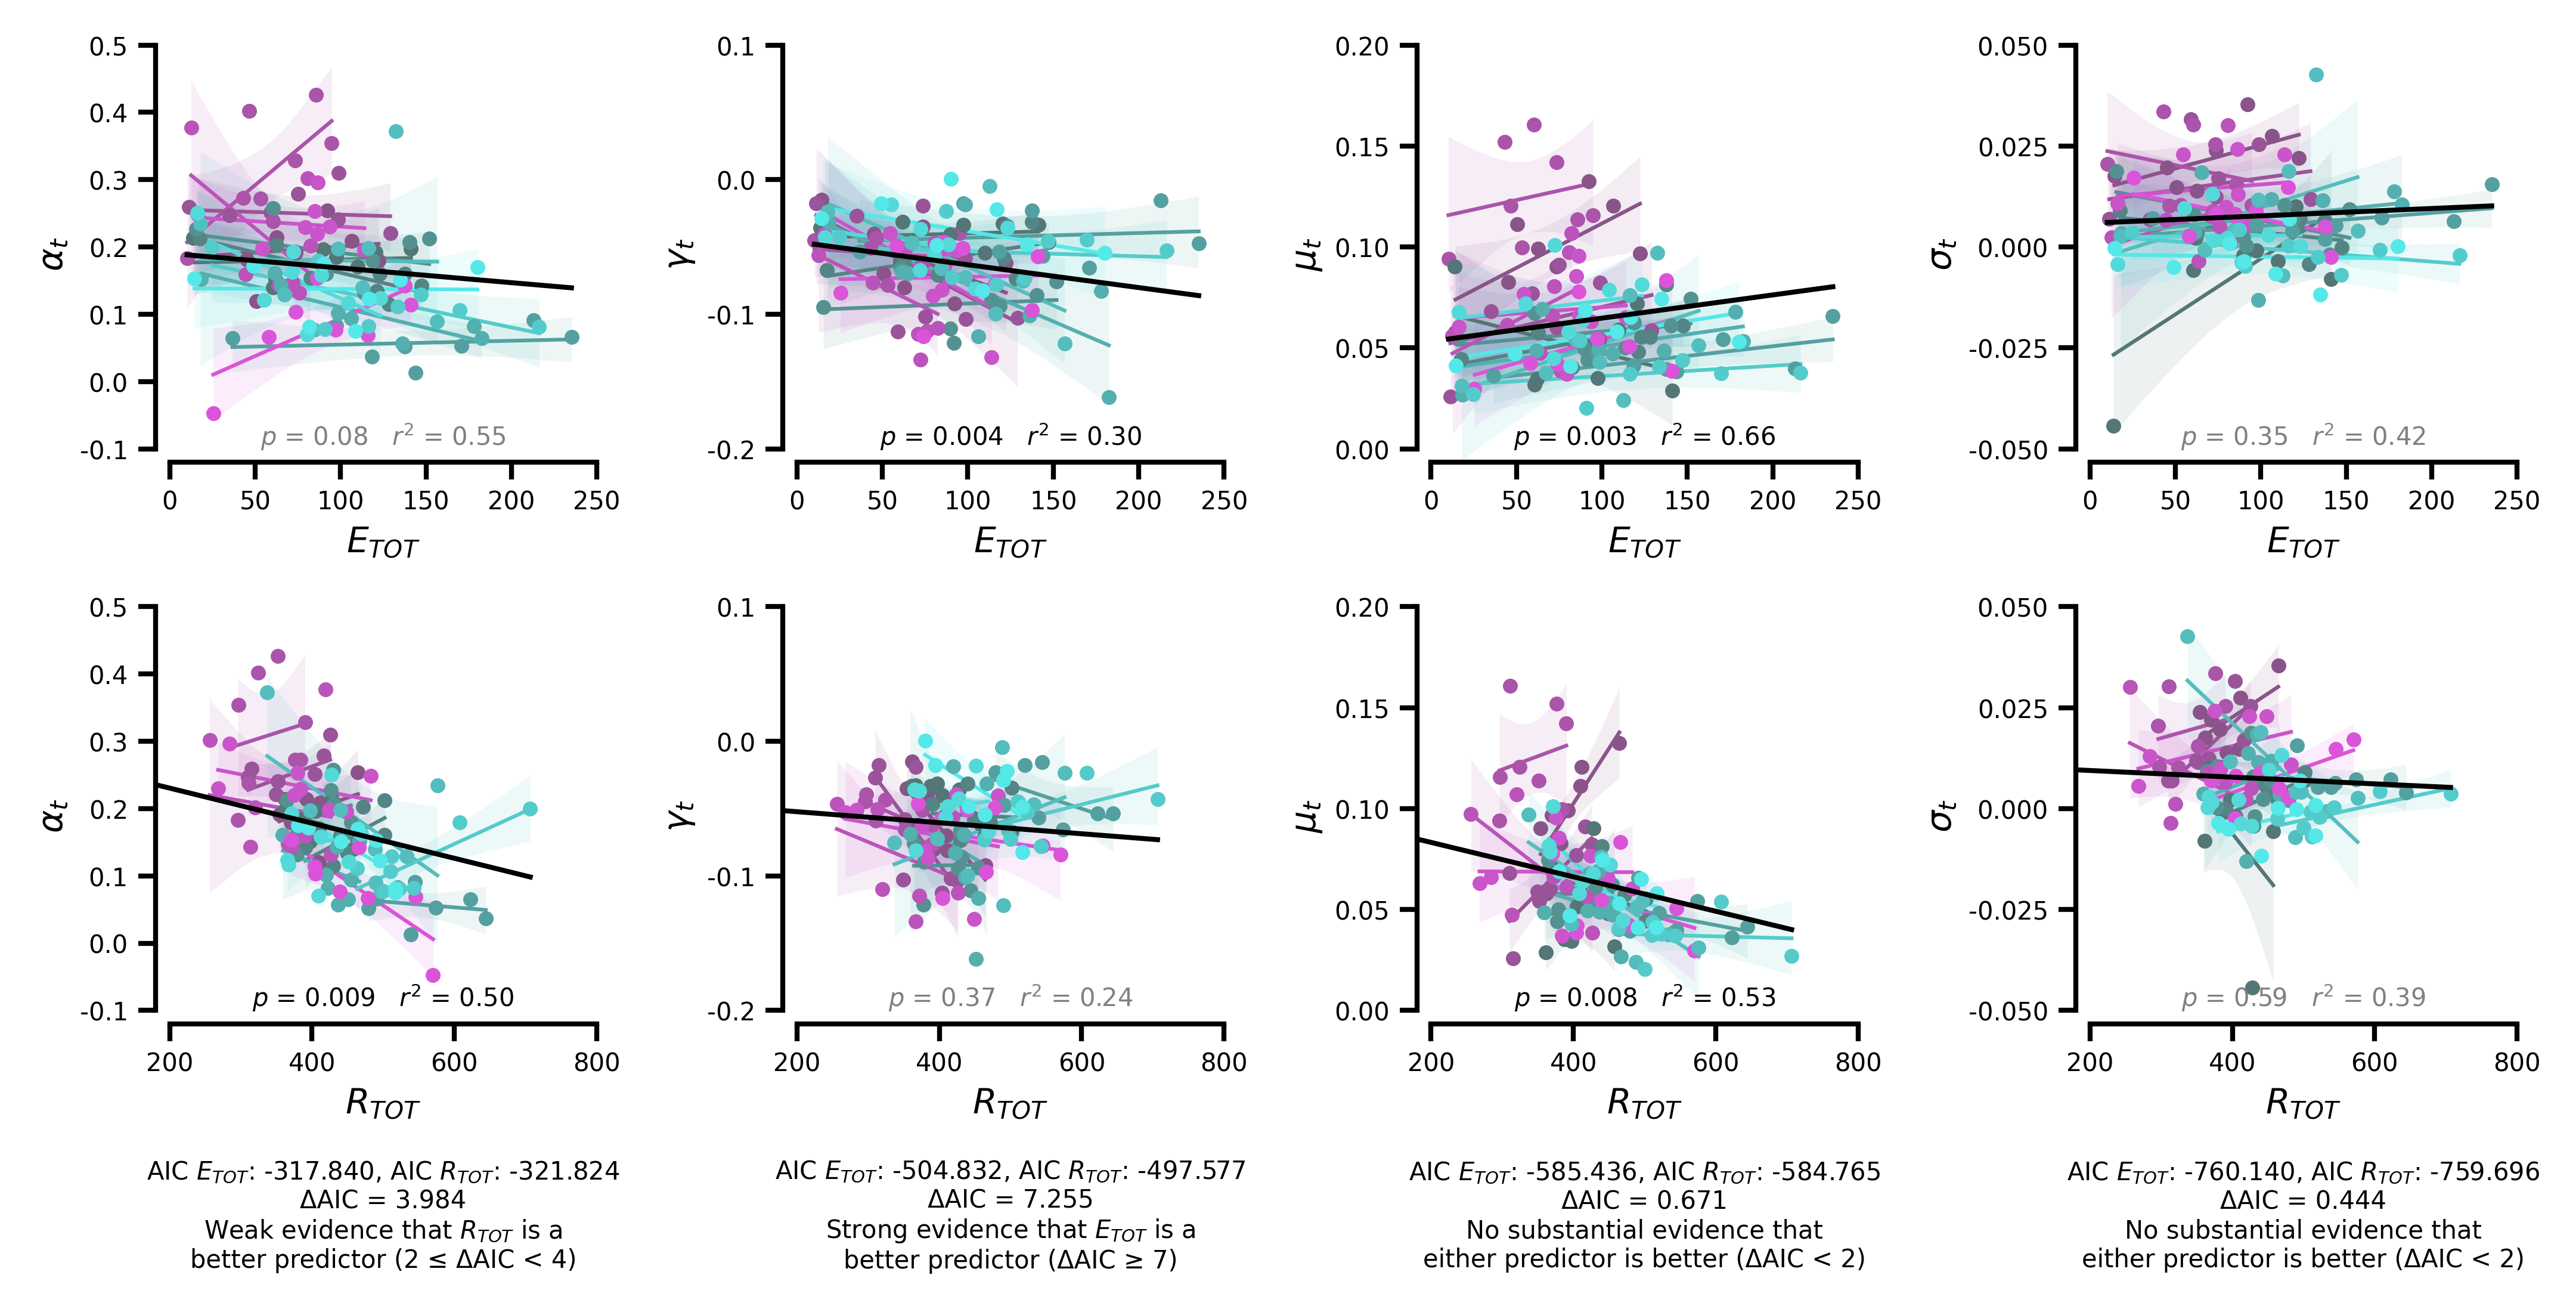

In [6]:
fig, axs = plt.subplots(3, 4, figsize=(cm2inch(18), cm2inch(9)), dpi=600,
                        constrained_layout=True, gridspec_kw={'height_ratios': [1, 1, 0.25]}, facecolor='w')

n = 8
print(f'p sig if < {0.05 / n:.3f}')
FigureSX(df, "total_effort", "alpha_t", _plot=True, ax=axs[0, 0])
FigureSX(df, "total_effort", "gamma_t", _plot=True, ax=axs[0, 1])
FigureSX(df, "total_effort", "mu_t", _plot=True, ax=axs[0, 2])
FigureSX(df, "total_effort", "sigma_t", _plot=True, ax=axs[0, 3])
FigureSX(df, "total_drops", "alpha_t", _plot=True, ax=axs[1, 0])
FigureSX(df, "total_drops", "gamma_t", _plot=True, ax=axs[1, 1])
FigureSX(df, "total_drops", "mu_t", _plot=True, ax=axs[1, 2])
FigureSX(df, "total_drops", "sigma_t", _plot=True, ax=axs[1, 3])


for i, name in enumerate(['alpha_t', 'gamma_t', 'mu_t', 'sigma_t']):
    plot_rule_of_thumb(name, ax=axs[2, i])

plt.savefig("./Figures_paper/Figure_SX.pdf", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)

plt.savefig("./Figures_paper/Figure_SX.svg", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="svg", dpi=600)